# Data Cleaning — UCM FibIoT 2024 Dataset

This notebook performs comprehensive data cleaning on three network traffic datasets from the **UCM FibIoT 2024** collection:

| Dataset | Attack Type | Description |
|---------|------------|-------------|
| `HTTP_flood.csv` | HTTP Flood | Application-layer DDoS attack |
| `ICMP_flood.csv` | ICMP Flood | Network-layer ping flood attack |
| `SYN_flood.csv` | SYN Flood | Transport-layer TCP SYN flood attack |

### Cleaning Steps
1. Load & inspect each dataset
2. Handle missing values
3. Remove duplicate rows
4. Fix data types (datetime, integers, categorical)
5. Standardize column names
6. Detect & handle outliers
7. Validate & export cleaned data

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set style for plots
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('[DONE] Libraries loaded successfully')

[DONE] Libraries loaded successfully


---
## 2. Load Datasets

In [2]:
# Define file paths
BASE_DIR = r'Dataset_UCM_FibIoT2024/Dataset_UCM_FibIoT2024'

datasets = {
  'HTTP_flood': os.path.join(BASE_DIR, 'HTTP flood', 'HTTP_flood.csv'),
  'ICMP_flood': os.path.join(BASE_DIR, 'ICMP flood', 'ICMP_flood.csv'),
  'SYN_flood': os.path.join(BASE_DIR, 'SYN flood', 'SYN_flood.csv'),
}

# Load all datasets
dfs = {}
for name, path in datasets.items():
  print(f'Loading {name}...')
  dfs[name] = pd.read_csv(path)
  print(f' [DONE] {name}: {dfs[name].shape[0]:,} rows x {dfs[name].shape[1]} columns')

print(f'\n Total rows across all datasets: {sum(df.shape[0] for df in dfs.values()):,}')

Loading HTTP_flood...
 [DONE] HTTP_flood: 10,799,707 rows x 8 columns
Loading ICMP_flood...
 [DONE] ICMP_flood: 11,203,031 rows x 8 columns
Loading SYN_flood...
 [DONE] SYN_flood: 22,780,665 rows x 8 columns

 Total rows across all datasets: 44,783,403


---
## 3. Initial Inspection

In [3]:
for name, df in dfs.items():
  print(f'\n{"=" * 60}')
  print(f' {name}')
  print(f'{"=" * 60}')
  print(f'\nShape: {df.shape}')
  print(f'\n--- Data Types ---')
  print(df.dtypes)
  print(f'\n--- First 5 Rows ---')
  display(df.head())
  print(f'\n--- Statistical Summary ---')
  display(df.describe(include='all'))


 HTTP_flood

Shape: (10799707, 8)

--- Data Types ---
No.                   int64
Time                 object
Source               object
Destination          object
Protocol             object
Length                int64
Source port         float64
Destination port    float64
dtype: object

--- First 5 Rows ---


,No.,Time,Source,Destination,Protocol,Length,Source port,Destination port
0,1,2024-03-25 18:54:26.096740,10.0.1.136,224.0.0.251,MDNS,117,5353.00,5353.00
1,2,2024-03-25 18:54:26.096852,fe80::1831:fc51:cbfc:cf7,ff02::fb,MDNS,137,5353.00,5353.00
2,3,2024-03-25 18:54:26.096946,10.0.1.136,224.0.0.251,MDNS,117,5353.00,5353.00
3,4,2024-03-25 18:54:26.097012,fe80::1831:fc51:cbfc:cf7,ff02::fb,MDNS,137,5353.00,5353.00
4,5,2024-03-25 18:54:26.097305,fe80::3c7e:beff:fec6:ba01,ff02::fb,MDNS,141,5353.00,5353.00



--- Statistical Summary ---


,No.,Time,Source,Destination,Protocol,Length,Source port,Destination port
count,10799707.00,10799707,10799707,10799707,10799707,10799707.00,10796437.00,10796437.00
unique,NaN,10529200,132,127,27,NaN,NaN,NaN
top,NaN,2024-03-25 18:57:36.194094,10.0.1.22,10.0.1.22,TCP,NaN,NaN,NaN
freq,NaN,4,4859392,5911972,7221511,NaN,NaN,NaN
mean,5399854.00,NaN,NaN,NaN,NaN,255.42,31627.52,26046.93
std,3117607.02,NaN,NaN,NaN,NaN,451.67,28565.28,28512.26
min,1.00,NaN,NaN,NaN,NaN,42.00,22.00,22.00
25%,2699927.50,NaN,NaN,NaN,NaN,60.00,443.00,443.00
50%,5399854.00,NaN,NaN,NaN,NaN,66.00,50636.00,500.00
75%,8099780.50,NaN,NaN,NaN,NaN,74.00,58036.00,56421.00



 ICMP_flood

Shape: (11203031, 8)

--- Data Types ---
No.                   int64
Time                 object
Source               object
Destination          object
Protocol             object
Length                int64
Source port         float64
Destination port    float64
dtype: object

--- First 5 Rows ---


...

,No.,Time,Source,Destination,Protocol,Length,Source port,Destination port
count,11203031.00,11203031,11203031,11203031,11203031,11203031.00,27668.00,27668.00
unique,NaN,11061501,11121481,1747,26,NaN,NaN,NaN
top,NaN,2024-03-25 18:25:17.856738,10.0.1.22,10.0.1.22,ICMP,NaN,NaN,NaN
freq,NaN,3,6602,11174499,11172532,NaN,NaN,NaN
mean,5601516.00,NaN,NaN,NaN,NaN,60.71,31280.62,24139.74
std,3234036.63,NaN,NaN,NaN,NaN,25.93,26051.22,25243.56
min,1.00,NaN,NaN,NaN,NaN,42.00,22.00,22.00
25%,2800758.50,NaN,NaN,NaN,NaN,60.00,993.00,993.00
50%,5601516.00,NaN,NaN,NaN,NaN,60.00,43342.00,7000.00
75%,8402273.50,NaN,NaN,NaN,NaN,60.00,56593.00,49607.00



 SYN_flood

Shape: (22780665, 8)

--- Data Types ---
No.                   int64
Time                 object
Source               object
Destination          object
Protocol             object
Length                int64
Source port         float64
Destination port    float64
dtype: object

--- First 5 Rows ---


,No.,Time,Source,Destination,Protocol,Length,Source port,Destination port
0,1,2024-03-25 17:35:46.987615,195.88.50.104,10.0.1.22,SSH,126,22.00,54520.00
1,2,2024-03-25 17:35:46.988108,10.0.1.22,195.88.50.104,TCP,66,54520.00,22.00
2,3,2024-03-25 17:35:46.988739,10.0.1.22,195.88.50.104,SSH,102,54520.00,22.00
3,4,2024-03-25 17:35:46.992141,10.0.1.58,255.255.255.255,UDP,60,52482.00,10001.00
4,5,2024-03-25 17:35:47.073084,195.88.50.104,10.0.1.22,TCP,66,22.00,54520.00



--- Statistical Summary ---


,No.,Time,Source,Destination,Protocol,Length,Source port,Destination port
count,22780665.00,22780665,22780665,22780665,22780665,22780665.00,22774778.00,22774778.00
unique,NaN,22600926,20936629,1327679,121,NaN,NaN,NaN
top,NaN,2024-03-25 17:36:46.935363,10.0.1.22,10.0.1.22,TCP,NaN,NaN,NaN
freq,NaN,3,1365298,21134794,8060484,NaN,NaN,NaN
mean,11390333.00,NaN,NaN,NaN,NaN,67.59,30900.37,2769.91
std,6576211.68,NaN,NaN,NaN,NaN,92.34,19909.90,10272.36
min,1.00,NaN,NaN,NaN,NaN,42.00,0.00,0.00
25%,5695167.00,NaN,NaN,NaN,NaN,60.00,13262.00,80.00
50%,11390333.00,NaN,NaN,NaN,NaN,60.00,30966.00,443.00
75%,17085499.00,NaN,NaN,NaN,NaN,60.00,48163.00,500.00


---
## 4. Missing Values Analysis


 HTTP_flood — Missing Values:


,Column,Missing Count,Missing %
6,Source port,3270,0.03
7,Destination port,3270,0.03



 ICMP_flood — Missing Values:


,Column,Missing Count,Missing %
6,Source port,11175363,99.75
7,Destination port,11175363,99.75



 SYN_flood — Missing Values:


,Column,Missing Count,Missing %
6,Source port,5887,0.03
7,Destination port,5887,0.03


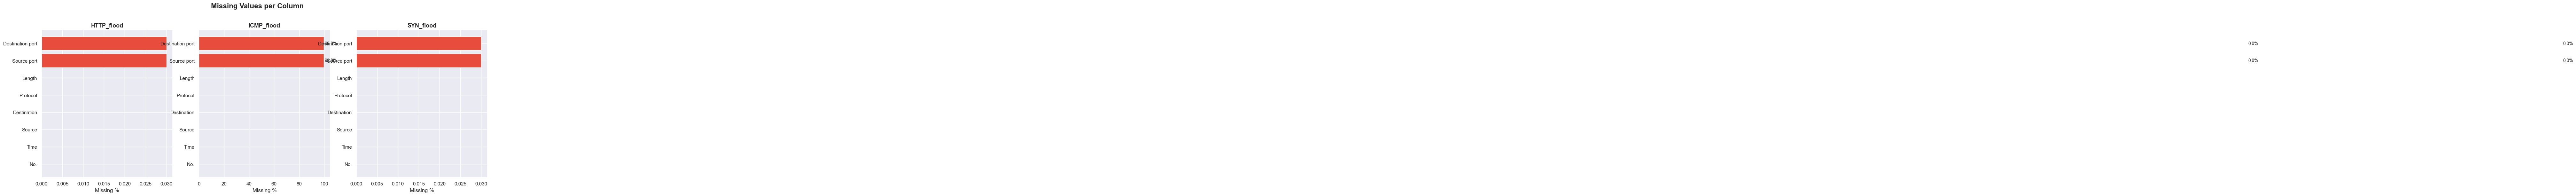

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Missing Values per Column', fontsize=16, fontweight='bold', y=1.02)

for idx, (name, df) in enumerate(dfs.items()):
  null_counts = df.isnull().sum()
  null_pct = (null_counts / len(df) * 100).round(2)
  
  # Create a summary dataframe
  null_df = pd.DataFrame({
    'Column': null_counts.index,
    'Missing Count': null_counts.values,
    'Missing %': null_pct.values
  })
  
  print(f'\n {name} — Missing Values:')
  display(null_df[null_df['Missing Count'] > 0] if null_df['Missing Count'].sum() > 0 
      else print(' No missing values! [DONE]'))
  
  # Bar plot
  colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in null_counts.values]
  axes[idx].barh(null_counts.index, null_pct.values, color=colors)
  axes[idx].set_title(name, fontsize=13, fontweight='bold')
  axes[idx].set_xlabel('Missing %')
  for i, v in enumerate(null_pct.values):
    if v > 0:
      axes[idx].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 5. Data Cleaning Pipeline

We define a reusable cleaning function that applies the following transformations to each dataset:

In [5]:
def clean_dataset(df, dataset_name):
  """
  Comprehensive cleaning pipeline for UCM FibIoT 2024 network traffic data.
  
  Parameters:
    df (pd.DataFrame): Raw dataframe
    dataset_name (str): Name identifier for logging
  
  Returns:
    pd.DataFrame: Cleaned dataframe
  """
  original_shape = df.shape
  print(f'\n{"=" * 60}')
  print(f' Cleaning: {dataset_name}')
  print(f'  Original shape: {original_shape}')
  print(f'{"=" * 60}')
  
  df_clean = df.copy()
  
  # ----------------------------------------------
  # Step 1: Standardize Column Names
  # ----------------------------------------------
  df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace('.', '', regex=False)
    .str.replace(' ', '_', regex=False)
  )
  print(f'\n [DONE] Step 1 — Standardized column names: {df_clean.columns.tolist()}')
  
  # ----------------------------------------------
  # Step 2: Drop the packet "no" column
  #  It's just a Wireshark capture index — not useful for analysis.
  # ----------------------------------------------
  if 'no' in df_clean.columns:
    df_clean = df_clean.drop(columns=['no'])
    print(f' [DONE] Step 2 — Dropped "no" column (Wireshark packet index)')
  
  # ----------------------------------------------
  # Step 3: Parse datetime
  # ----------------------------------------------
  df_clean['time'] = pd.to_datetime(df_clean['time'], errors='coerce')
  bad_times = df_clean['time'].isnull().sum()
  if bad_times > 0:
    print(f' [WARNING] Step 3 — {bad_times:,} rows with unparseable timestamps (dropped)')
    df_clean = df_clean.dropna(subset=['time'])
  else:
    print(f' [DONE] Step 3 — All timestamps parsed successfully')
  
  # ----------------------------------------------
  # Step 4: Handle missing port values
  #  Protocols like ARP, ICMP, ICMPv6, LLDP don't use ports.
  #  For these, NaN is expected -> fill with -1 sentinel.
  #  For port-based protocols (TCP/UDP), missing ports are errors -> drop.
  # ----------------------------------------------
  portless_protocols = ['ARP', 'ICMP', 'ICMPv6', 'LLDP']
  
  # Rows where ports are NaN *and* protocol doesn't need ports -> fill with -1
  portless_mask = (
    df_clean['protocol'].str.upper().isin([p.upper() for p in portless_protocols])
  )
  portna_mask = df_clean['source_port'].isnull() | df_clean['destination_port'].isnull()
  
  expected_na = (portless_mask & portna_mask).sum()
  unexpected_na = (~portless_mask & portna_mask).sum()
  
  # Fill expected NaN ports with -1
  df_clean.loc[portless_mask, ['source_port', 'destination_port']] = (
    df_clean.loc[portless_mask, ['source_port', 'destination_port']].fillna(-1)
  )
  
  # Drop rows with unexpected NaN ports
  if unexpected_na > 0:
    df_clean = df_clean.dropna(subset=['source_port', 'destination_port'])
    print(f' [WARNING] Step 4 — Filled {expected_na:,} expected NaN ports (portless protocols like ARP/ICMP)')
    print(f'       Dropped {unexpected_na:,} rows with unexpected NaN ports')
  else:
    print(f' [DONE] Step 4 — Handled {expected_na:,} NaN ports from portless protocols (ARP/ICMP -> filled -1)')
  
  # Convert ports to integer type
  df_clean['source_port'] = df_clean['source_port'].astype(int)
  df_clean['destination_port'] = df_clean['destination_port'].astype(int)
  
  # ----------------------------------------------
  # Step 5: Remove exact duplicate rows
  # ----------------------------------------------
  n_dupes = df_clean.duplicated().sum()
  if n_dupes > 0:
    df_clean = df_clean.drop_duplicates()
    print(f' [WARNING] Step 5 — Removed {n_dupes:,} duplicate rows')
  else:
    print(f' [DONE] Step 5 — No duplicate rows found')
  
  # ----------------------------------------------
  # Step 6: Strip whitespace from string columns
  # ----------------------------------------------
  str_cols = df_clean.select_dtypes(include='object').columns
  for col in str_cols:
    df_clean[col] = df_clean[col].str.strip()
  print(f' [DONE] Step 6 — Stripped whitespace from {len(str_cols)} string columns')
  
  # ----------------------------------------------
  # Step 7: Validate packet length (must be > 0)
  # ----------------------------------------------
  invalid_len = (df_clean['length'] <= 0).sum()
  if invalid_len > 0:
    df_clean = df_clean[df_clean['length'] > 0]
    print(f' [WARNING] Step 7 — Removed {invalid_len:,} rows with invalid packet length (<= 0)')
  else:
    print(f' [DONE] Step 7 — All packet lengths are valid (> 0)')
  
  # ----------------------------------------------
  # Step 8: Validate port ranges (0-65535 or -1 sentinel)
  # ----------------------------------------------
  valid_port_mask = (
    ((df_clean['source_port'] >= 0) & (df_clean['source_port'] <= 65535) | (df_clean['source_port'] == -1)) &
    ((df_clean['destination_port'] >= 0) & (df_clean['destination_port'] <= 65535) | (df_clean['destination_port'] == -1))
  )
  invalid_ports = (~valid_port_mask).sum()
  if invalid_ports > 0:
    df_clean = df_clean[valid_port_mask]
    print(f' [WARNING] Step 8 — Removed {invalid_ports:,} rows with invalid port values')
  else:
    print(f' [DONE] Step 8 — All port values are within valid range (0-65535 or -1)')
  
  # ----------------------------------------------
  # Step 9: Convert protocol to categorical (memory optimization)
  # ----------------------------------------------
  df_clean['protocol'] = df_clean['protocol'].astype('category')
  print(f' [DONE] Step 9 — Converted protocol to categorical ({df_clean["protocol"].nunique()} unique protocols)')
  
  # ----------------------------------------------
  # Step 10: Sort by time and reset index
  # ----------------------------------------------
  df_clean = df_clean.sort_values('time').reset_index(drop=True)
  print(f' [DONE] Step 10 — Sorted by time & reset index')
  
  # ----------------------------------------------
  # Step 11: Add attack label
  # ----------------------------------------------
  attack_label = dataset_name.replace('_', ' ').title()
  df_clean['attack_type'] = attack_label
  df_clean['attack_type'] = df_clean['attack_type'].astype('category')
  print(f' [DONE] Step 11 — Added attack label: "{attack_label}"')
  
  # ----------------------------------------------
  # Summary
  # ----------------------------------------------
  final_shape = df_clean.shape
  rows_removed = original_shape[0] - final_shape[0]
  pct_removed = (rows_removed / original_shape[0] * 100)
  print(f'\n  Final shape: {final_shape}')
  print(f'  Rows removed: {rows_removed:,} ({pct_removed:.2f}%)')
  
  return df_clean

---
## 6. Apply Cleaning Pipeline

In [6]:
dfs_cleaned = {}
for name, df in dfs.items():
  dfs_cleaned[name] = clean_dataset(df, name)


 Cleaning: HTTP_flood
  Original shape: (10799707, 8)

 [DONE] Step 1 — Standardized column names: ['no', 'time', 'source', 'destination', 'protocol', 'length', 'source_port', 'destination_port']
 [DONE] Step 2 — Dropped "no" column (Wireshark packet index)
 [DONE] Step 3 — All timestamps parsed successfully
 [WARNING] Step 4 — Filled 3,196 expected NaN ports (portless protocols like ARP/ICMP)
       Dropped 74 rows with unexpected NaN ports
 [WARNING] Step 5 — Removed 107 duplicate rows
 [DONE] Step 6 — Stripped whitespace from 3 string columns
 [DONE] Step 7 — All packet lengths are valid (> 0)
 [DONE] Step 8 — All port values are within valid range (0-65535 or -1)
 [DONE] Step 9 — Converted protocol to categorical (23 unique protocols)
 [DONE] Step 10 — Sorted by time & reset index
 [DONE] Step 11 — Added attack label: "Http Flood"

  Final shape: (10799526, 8)
  Rows removed: 181 (0.00%)

 Cleaning: ICMP_flood
  Original shape: (11203031, 8)

 [DONE] Step 1 — Standardized column n

---
## 7. Post-Cleaning Validation

In [7]:
print('=' * 70)
print(' POST-CLEANING VALIDATION REPORT')
print('=' * 70)

summary_rows = []
for name, df in dfs_cleaned.items():
  orig = dfs[name].shape[0]
  cleaned = df.shape[0]
  removed = orig - cleaned
  
  summary_rows.append({
    'Dataset': name,
    'Original Rows': f'{orig:,}',
    'Cleaned Rows': f'{cleaned:,}',
    'Rows Removed': f'{removed:,}',
    'Removal %': f'{removed/orig*100:.2f}%',
    'Nulls Remaining': df.isnull().sum().sum(),
    'Duplicates Remaining': df.duplicated().sum()
  })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# Validate no nulls remain
for name, df in dfs_cleaned.items():
  assert df.isnull().sum().sum() == 0, f'{name} still has null values!'
  assert df.duplicated().sum() == 0, f'{name} still has duplicates!'

print('\n[DONE] All validations passed — no nulls, no duplicates.')

 POST-CLEANING VALIDATION REPORT


,Dataset,Original Rows,Cleaned Rows,Rows Removed,Removal %,Nulls Remaining,Duplicates Remaining
0,HTTP_flood,"10,799,707","10,799,526",181,0.00%,0,0
1,ICMP_flood,"11,203,031","11,202,929",102,0.00%,0,0
2,SYN_flood,"22,780,665","22,780,333",332,0.00%,0,0



[DONE] All validations passed — no nulls, no duplicates.


In [8]:
# Inspect cleaned data types & sample
for name, df in dfs_cleaned.items():
  print(f'\n{"=" * 60}')
  print(f' {name} (Cleaned)')
  print(f'{"=" * 60}')
  print(f'\nData Types:')
  print(df.dtypes)
  print(f'\nSample (first 5 rows):')
  display(df.head())

---
## 8. Post-Cleaning Visualizations

In [9]:
# Protocol distribution per dataset
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Protocol Distribution (After Cleaning)', fontsize=16, fontweight='bold', y=1.02)

for idx, (name, df) in enumerate(dfs_cleaned.items()):
  proto_counts = df['protocol'].value_counts().head(10)
  colors = sns.color_palette('viridis', len(proto_counts))
  proto_counts.plot(kind='barh', ax=axes[idx], color=colors)
  axes[idx].set_title(name, fontsize=13, fontweight='bold')
  axes[idx].set_xlabel('Count')
  axes[idx].set_ylabel('')
  
  # Add value labels
  for i, v in enumerate(proto_counts.values):
    axes[idx].text(v + proto_counts.max() * 0.01, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

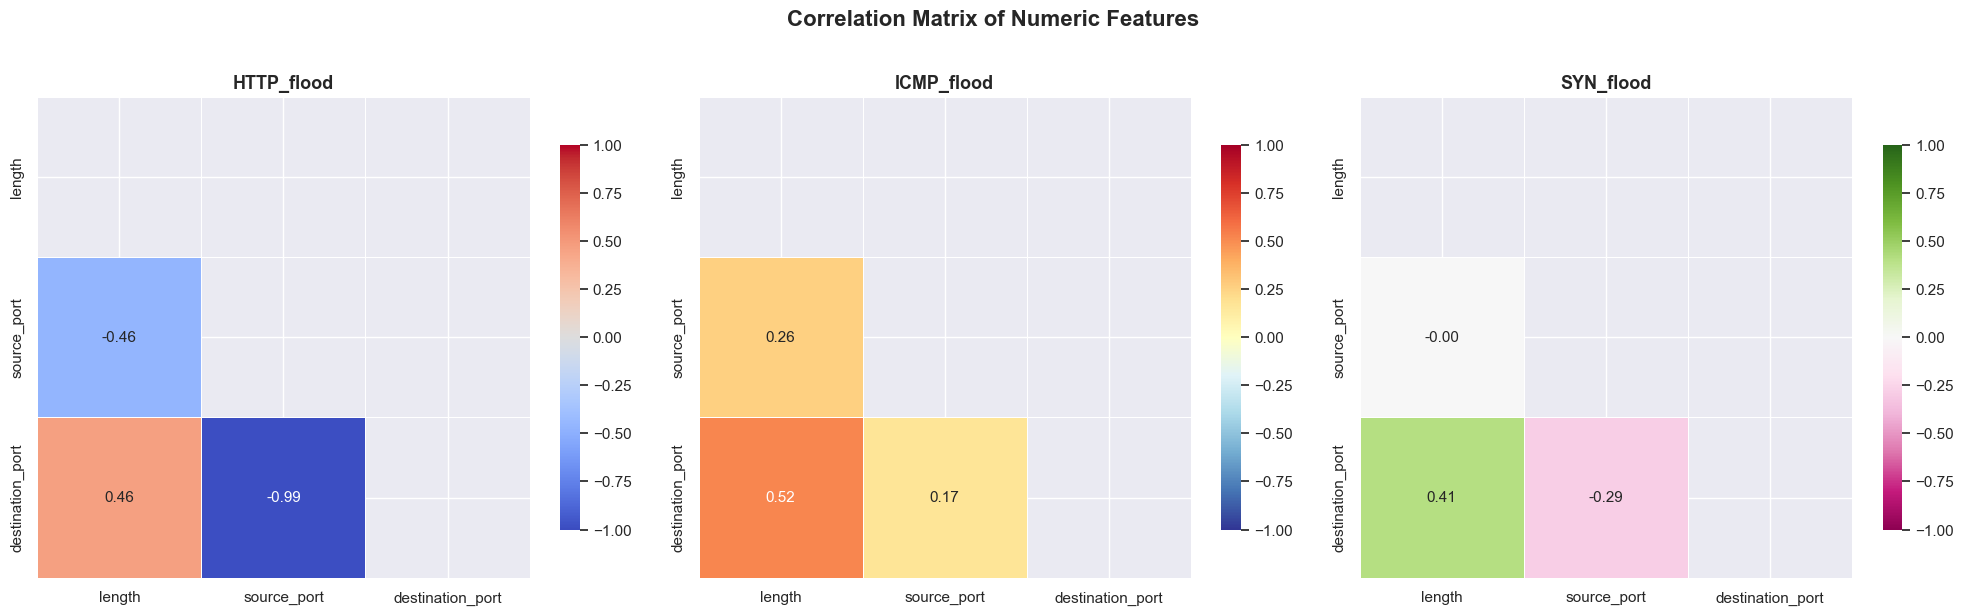

In [10]:
# Packet length distribution per dataset
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Packet Length Distribution (After Cleaning)', fontsize=16, fontweight='bold', y=1.02)

for idx, (name, df) in enumerate(dfs_cleaned.items()):
  df['length'].plot(kind='hist', bins=50, ax=axes[idx], color='#3498db', edgecolor='white', alpha=0.8)
  axes[idx].set_title(name, fontsize=13, fontweight='bold')
  axes[idx].set_xlabel('Packet Length (bytes)')
  axes[idx].set_ylabel('Frequency')
  
  # Add stats
  stats_text = f'Mean: {df["length"].mean():.0f}\nMedian: {df["length"].median():.0f}\nStd: {df["length"].std():.0f}'
  axes[idx].text(0.95, 0.95, stats_text, transform=axes[idx].transAxes,
          fontsize=9, va='top', ha='right',
          bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

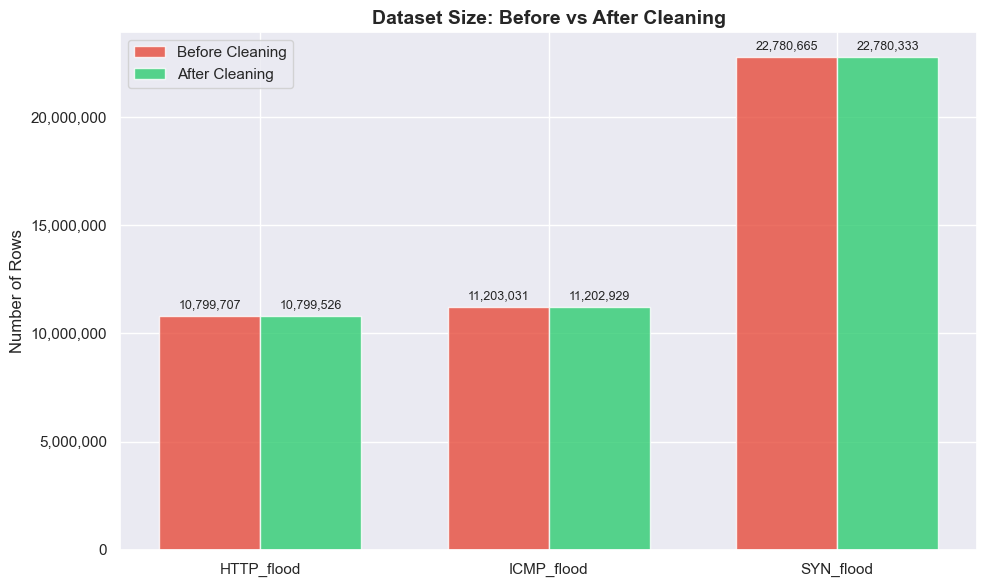

In [11]:
# Dataset size comparison (before vs after)
fig, ax = plt.subplots(figsize=(10, 6))

names = list(dfs.keys())
before_counts = [dfs[n].shape[0] for n in names]
after_counts = [dfs_cleaned[n].shape[0] for n in names]

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, before_counts, width, label='Before Cleaning', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, after_counts, width, label='After Cleaning', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Number of Rows', fontsize=12)
ax.set_title('Dataset Size: Before vs After Cleaning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: f'{val:,.0f}'))

# Add value labels
for bar in bars1:
  ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(before_counts)*0.01,
      f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
  ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(before_counts)*0.01,
      f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 8.4 Top Source IPs per Attack Type

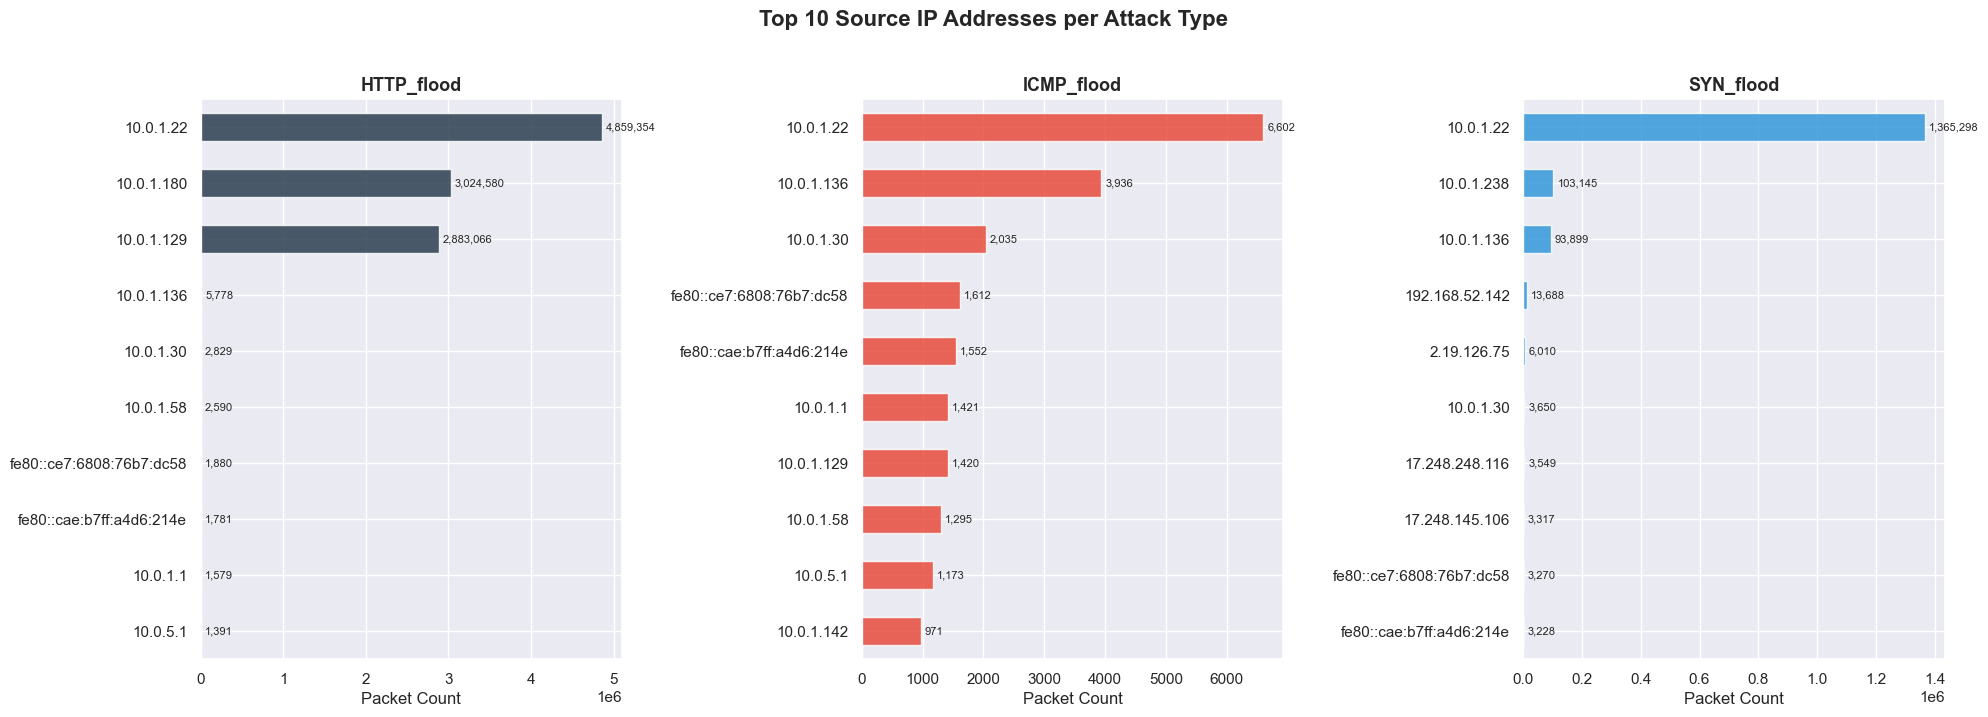

In [12]:
# Top 10 source IP addresses per dataset
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Top 10 Source IP Addresses per Attack Type', fontsize=16, fontweight='bold', y=1.02)

palette = ['#2c3e50', '#e74c3c', '#3498db']
for idx, (name, df) in enumerate(dfs_cleaned.items()):
    top_src = df['source'].value_counts().head(10)
    top_src.plot(kind='barh', ax=axes[idx], color=palette[idx], edgecolor='white', alpha=0.85)
    axes[idx].set_title(name, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Packet Count')
    axes[idx].set_ylabel('')
    axes[idx].invert_yaxis()
    for i, v in enumerate(top_src.values):
        axes[idx].text(v + top_src.max() * 0.01, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 8.5 Top Destination IPs per Attack Type

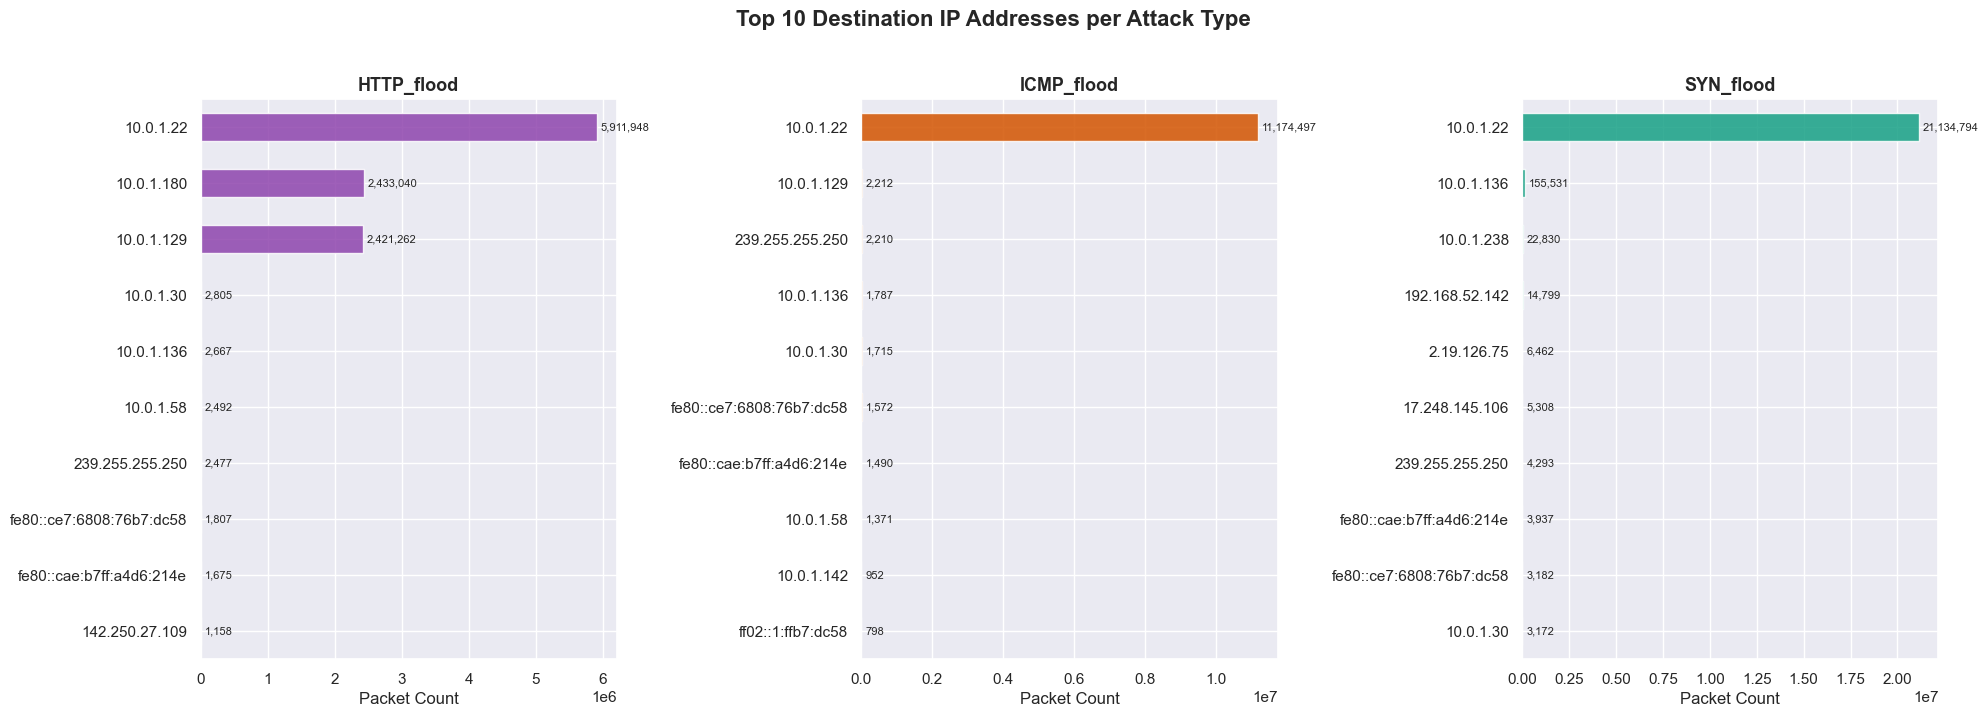

In [13]:
# Top 10 destination IP addresses per dataset
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Top 10 Destination IP Addresses per Attack Type', fontsize=16, fontweight='bold', y=1.02)

palette = ['#8e44ad', '#d35400', '#16a085']
for idx, (name, df) in enumerate(dfs_cleaned.items()):
    top_dst = df['destination'].value_counts().head(10)
    top_dst.plot(kind='barh', ax=axes[idx], color=palette[idx], edgecolor='white', alpha=0.85)
    axes[idx].set_title(name, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Packet Count')
    axes[idx].set_ylabel('')
    axes[idx].invert_yaxis()
    for i, v in enumerate(top_dst.values):
        axes[idx].text(v + top_dst.max() * 0.01, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 8.6 Traffic Volume Over Time (Time Series)

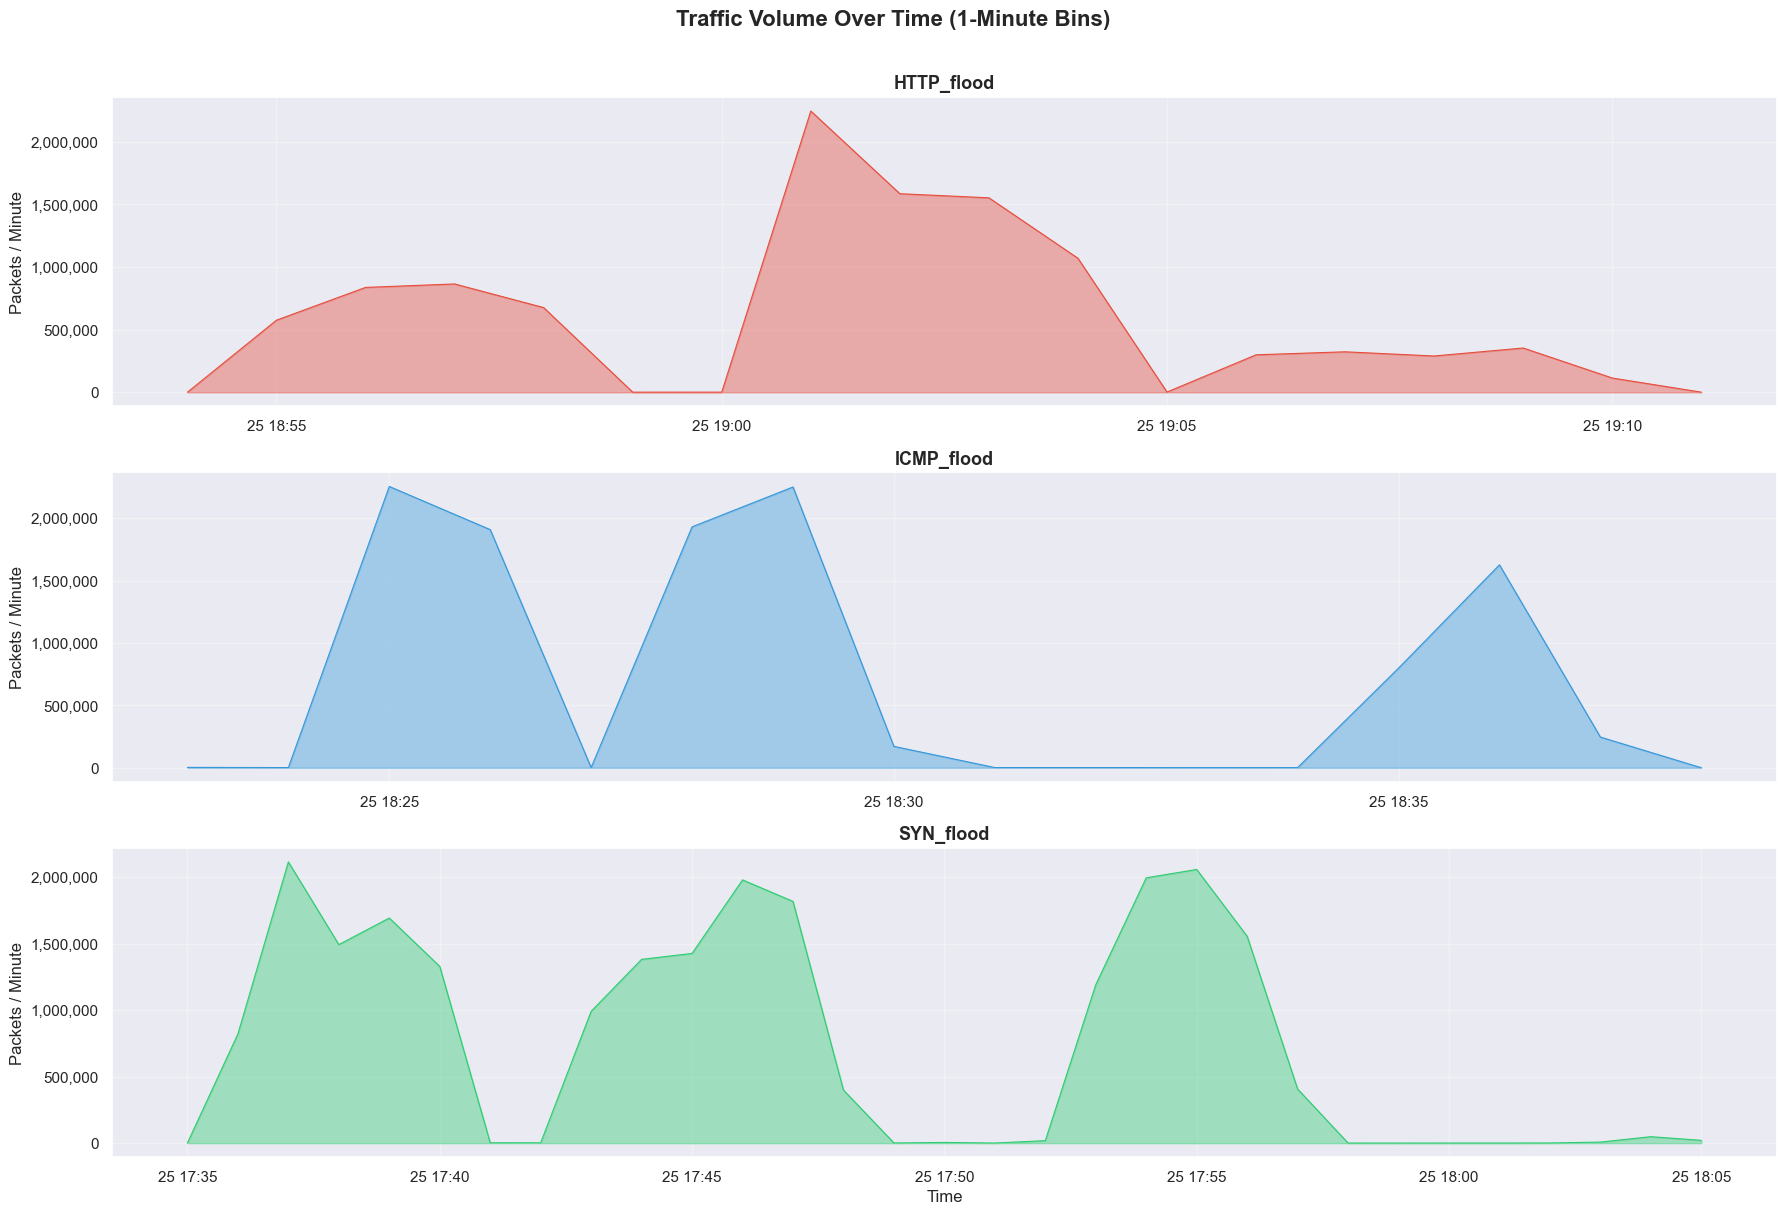

In [14]:
# Traffic volume over time - packets per minute
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=False)
fig.suptitle('Traffic Volume Over Time (1-Minute Bins)', fontsize=16, fontweight='bold', y=1.01)

colors = ['#e74c3c', '#3498db', '#2ecc71']
for idx, (name, df) in enumerate(dfs_cleaned.items()):
    ts = df.set_index('time').resample('1min').size()
    axes[idx].fill_between(ts.index, ts.values, alpha=0.4, color=colors[idx])
    axes[idx].plot(ts.index, ts.values, color=colors[idx], linewidth=0.8)
    axes[idx].set_title(name, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Packets / Minute')
    axes[idx].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v:,.0f}'))
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

### 8.7 Packet Length Box Plots (Outlier Detection)

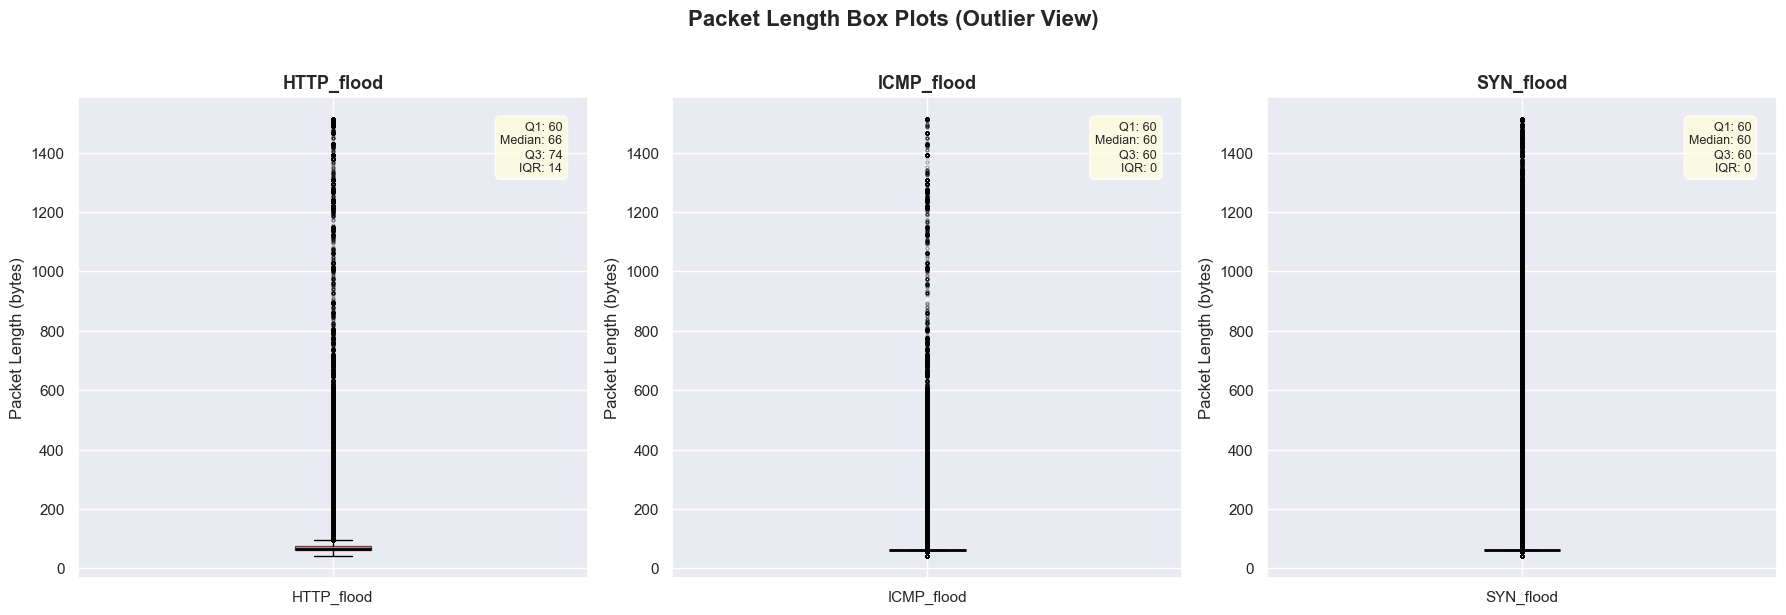

In [15]:
# Box plots of packet length per dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Packet Length Box Plots (Outlier View)', fontsize=16, fontweight='bold', y=1.02)

colors = ['#e74c3c', '#3498db', '#2ecc71']
for idx, (name, df) in enumerate(dfs_cleaned.items()):
    bp = axes[idx].boxplot(df['length'], vert=True, patch_artist=True,
                          boxprops=dict(facecolor=colors[idx], alpha=0.6),
                          medianprops=dict(color='black', linewidth=2),
                          flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[idx].set_title(name, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Packet Length (bytes)')
    axes[idx].set_xticklabels([name])

    q1 = df['length'].quantile(0.25)
    q3 = df['length'].quantile(0.75)
    med = df['length'].median()
    stats_text = f'Q1: {q1:.0f}\nMedian: {med:.0f}\nQ3: {q3:.0f}\nIQR: {q3-q1:.0f}'
    axes[idx].text(0.95, 0.95, stats_text, transform=axes[idx].transAxes,
                   fontsize=9, va='top', ha='right',
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

### 8.8 Port Usage Heatmap (Top Source vs Destination Ports)

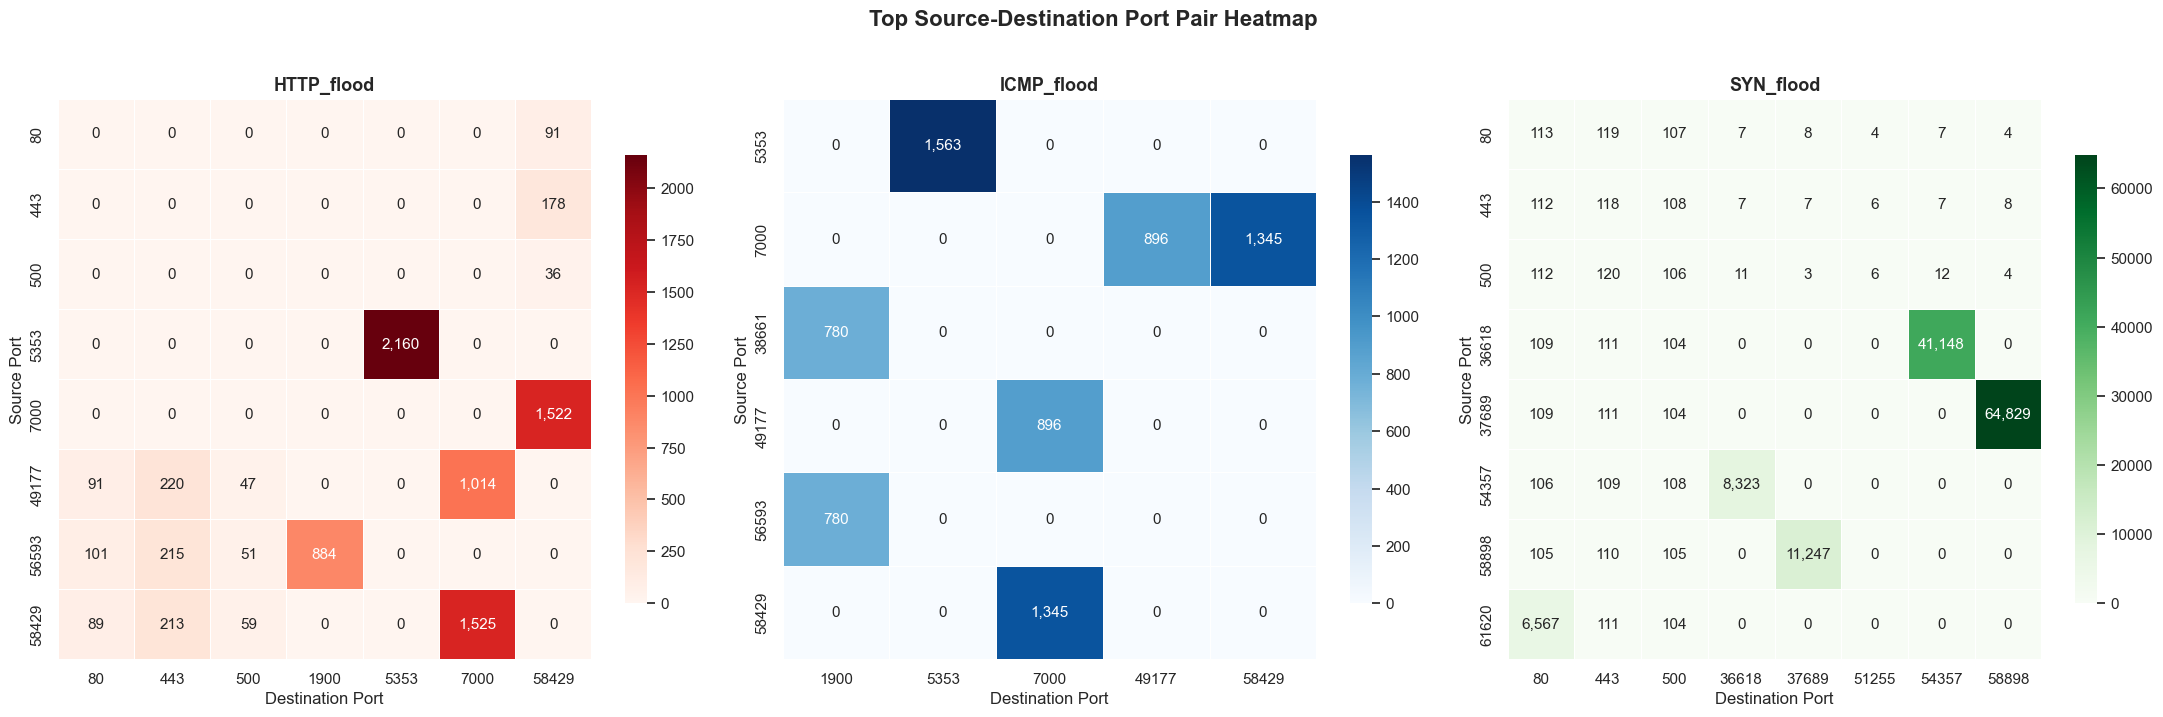

In [16]:
# Heatmap of top source port vs destination port combinations
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Top Source-Destination Port Pair Heatmap', fontsize=16, fontweight='bold', y=1.02)

cmaps = ['Reds', 'Blues', 'Greens']
for idx, (name, df) in enumerate(dfs_cleaned.items()):
    df_ports = df[(df['source_port'] != -1) & (df['destination_port'] != -1)]
    if len(df_ports) == 0:
        axes[idx].text(0.5, 0.5, 'No port-based traffic', ha='center', va='center', fontsize=12)
        axes[idx].set_title(name, fontsize=13, fontweight='bold')
        continue

    top_src_ports = df_ports['source_port'].value_counts().head(8).index.tolist()
    top_dst_ports = df_ports['destination_port'].value_counts().head(8).index.tolist()

    filtered = df_ports[df_ports['source_port'].isin(top_src_ports) & df_ports['destination_port'].isin(top_dst_ports)]
    pivot = filtered.groupby(['source_port', 'destination_port']).size().unstack(fill_value=0)

    sns.heatmap(pivot, ax=axes[idx], cmap=cmaps[idx], annot=True, fmt=',d',
                linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
    axes[idx].set_title(name, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Destination Port')
    axes[idx].set_ylabel('Source Port')

plt.tight_layout()
plt.show()

### 8.9 Protocol Proportion (Pie Charts)

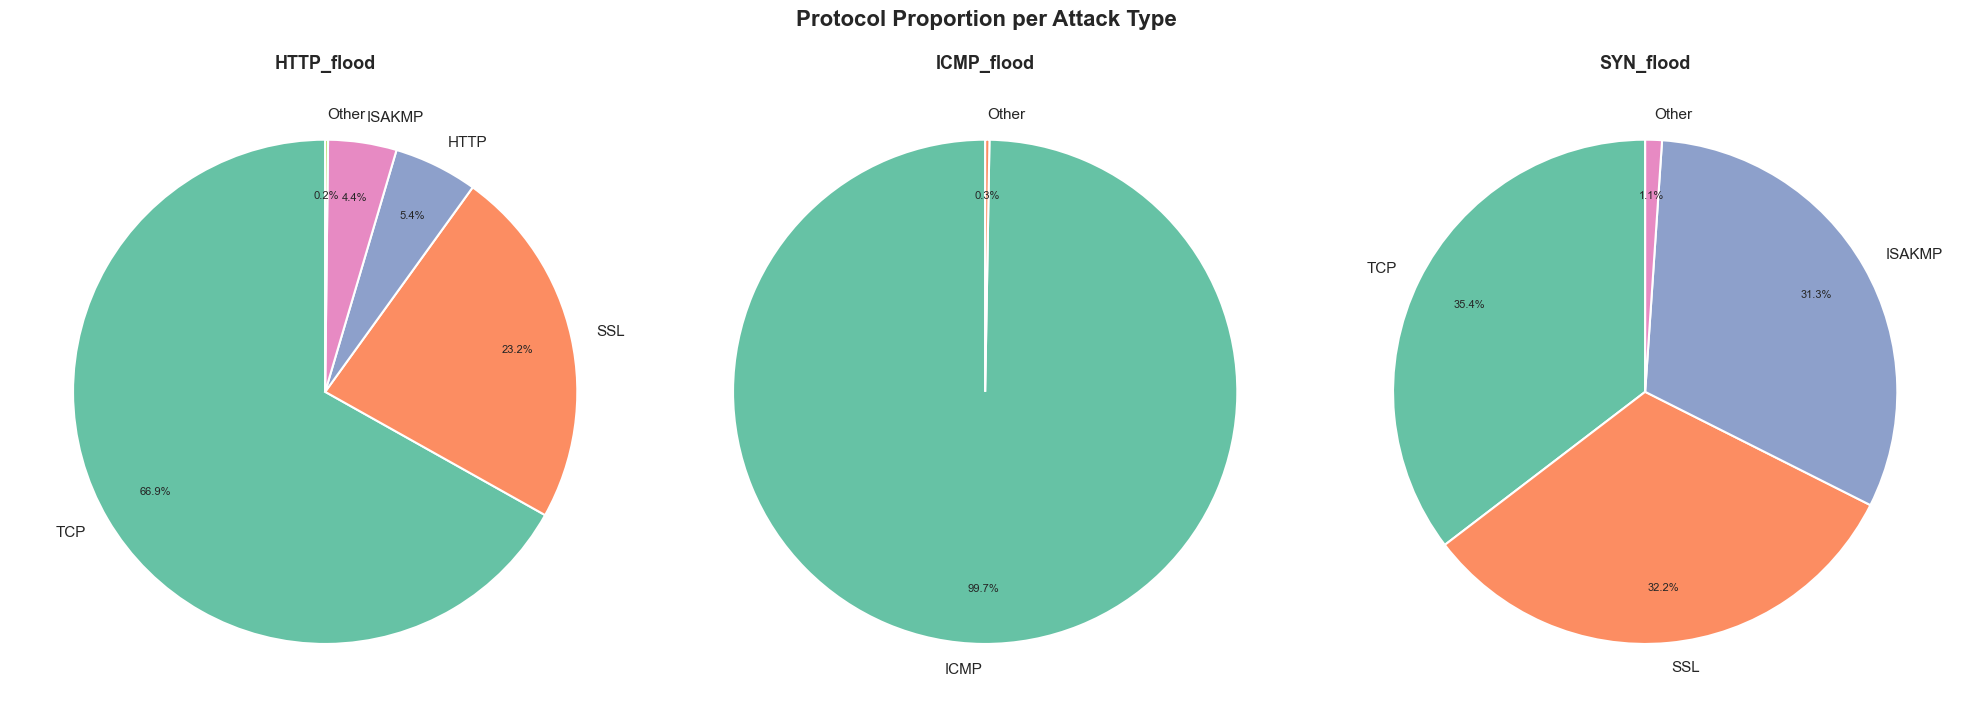

In [17]:
# Pie charts showing protocol proportion per dataset
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Protocol Proportion per Attack Type', fontsize=16, fontweight='bold', y=1.02)

for idx, (name, df) in enumerate(dfs_cleaned.items()):
    proto_counts = df['protocol'].value_counts()
    threshold = 0.02 * len(df)
    main = proto_counts[proto_counts >= threshold].copy()
    other_count = proto_counts[proto_counts < threshold].sum()
    if other_count > 0:
        main['Other'] = other_count

    colors = sns.color_palette('Set2', len(main))
    wedges, texts, autotexts = axes[idx].pie(
        main.values, labels=main.index, autopct='%1.1f%%',
        colors=colors, startangle=90, pctdistance=0.78,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for t in autotexts:
        t.set_fontsize(8)
    axes[idx].set_title(name, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 8.10 Packet Length by Protocol (Violin Plots)

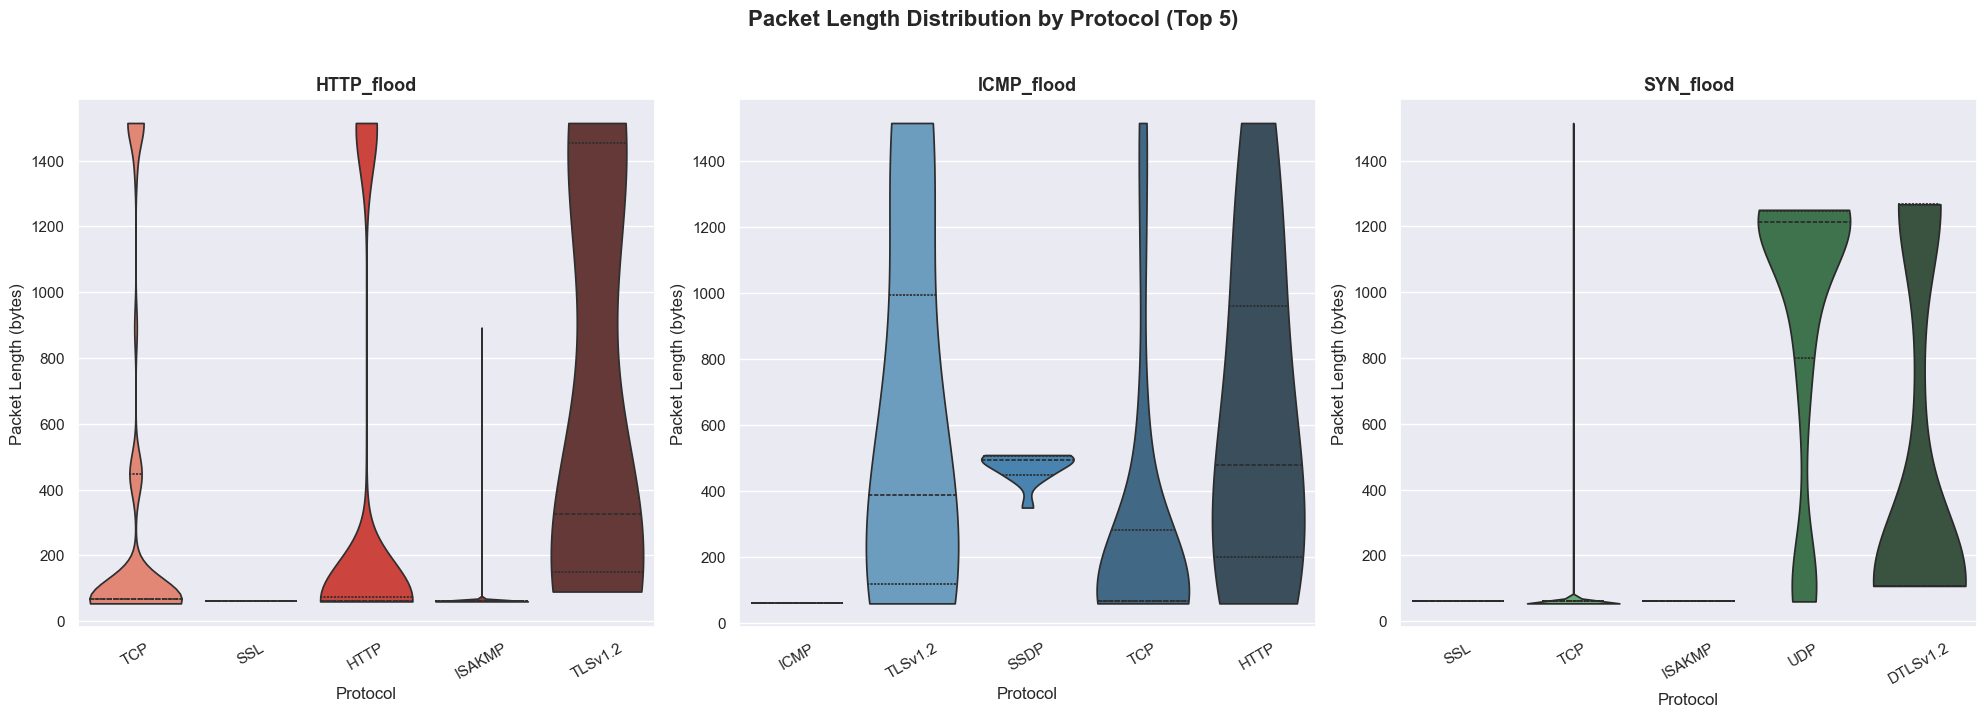

In [18]:
# Violin plots of packet length grouped by top protocols
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Packet Length Distribution by Protocol (Top 5)', fontsize=16, fontweight='bold', y=1.02)

palettes = ['Reds_d', 'Blues_d', 'Greens_d']
for idx, (name, df) in enumerate(dfs_cleaned.items()):
    top_protos = df['protocol'].value_counts().head(5).index.tolist()
    df_sub = df[df['protocol'].isin(top_protos)].copy()
    df_sub['protocol'] = df_sub['protocol'].astype(str)

    # Sample for performance
    sample_size = min(50000, len(df_sub))
    df_sample = df_sub.sample(n=sample_size, random_state=42)

    sns.violinplot(data=df_sample, x='protocol', y='length', ax=axes[idx],
                   palette=palettes[idx], inner='quartile', cut=0)
    axes[idx].set_title(name, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Protocol')
    axes[idx].set_ylabel('Packet Length (bytes)')
    axes[idx].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 8.11 Combined Attack Type Comparison

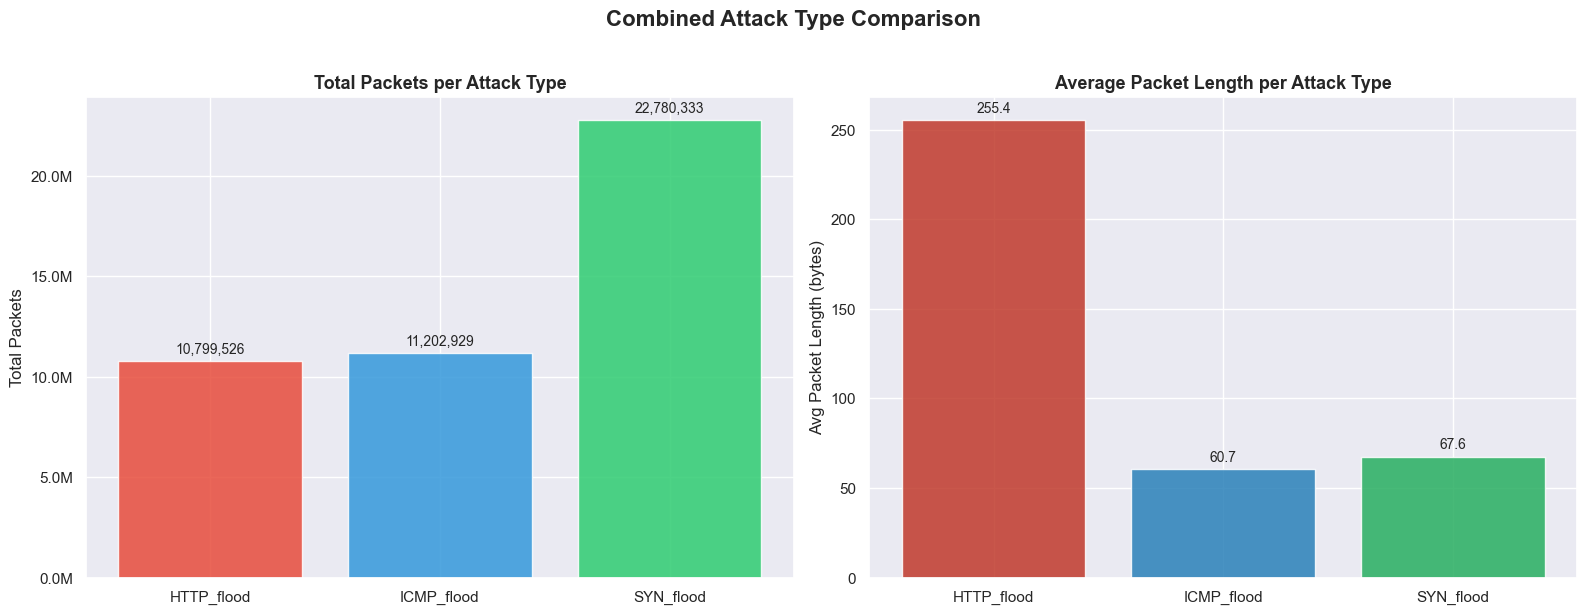

In [19]:
# Combined view: total packet counts and avg packet length per attack
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Combined Attack Type Comparison', fontsize=16, fontweight='bold', y=1.02)

attack_names = list(dfs_cleaned.keys())
total_packets = [len(df) for df in dfs_cleaned.values()]
avg_lengths = [df['length'].mean() for df in dfs_cleaned.values()]

bars = ax1.bar(attack_names, total_packets, color=['#e74c3c', '#3498db', '#2ecc71'],
               edgecolor='white', alpha=0.85)
ax1.set_title('Total Packets per Attack Type', fontsize=13, fontweight='bold')
ax1.set_ylabel('Total Packets')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v/1e6:.1f}M'))
for bar, val in zip(bars, total_packets):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(total_packets)*0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

bars2 = ax2.bar(attack_names, avg_lengths, color=['#c0392b', '#2980b9', '#27ae60'],
                edgecolor='white', alpha=0.85)
ax2.set_title('Average Packet Length per Attack Type', fontsize=13, fontweight='bold')
ax2.set_ylabel('Avg Packet Length (bytes)')
for bar, val in zip(bars2, avg_lengths):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(avg_lengths)*0.01,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 8.12 Correlation Heatmap (Numeric Features)

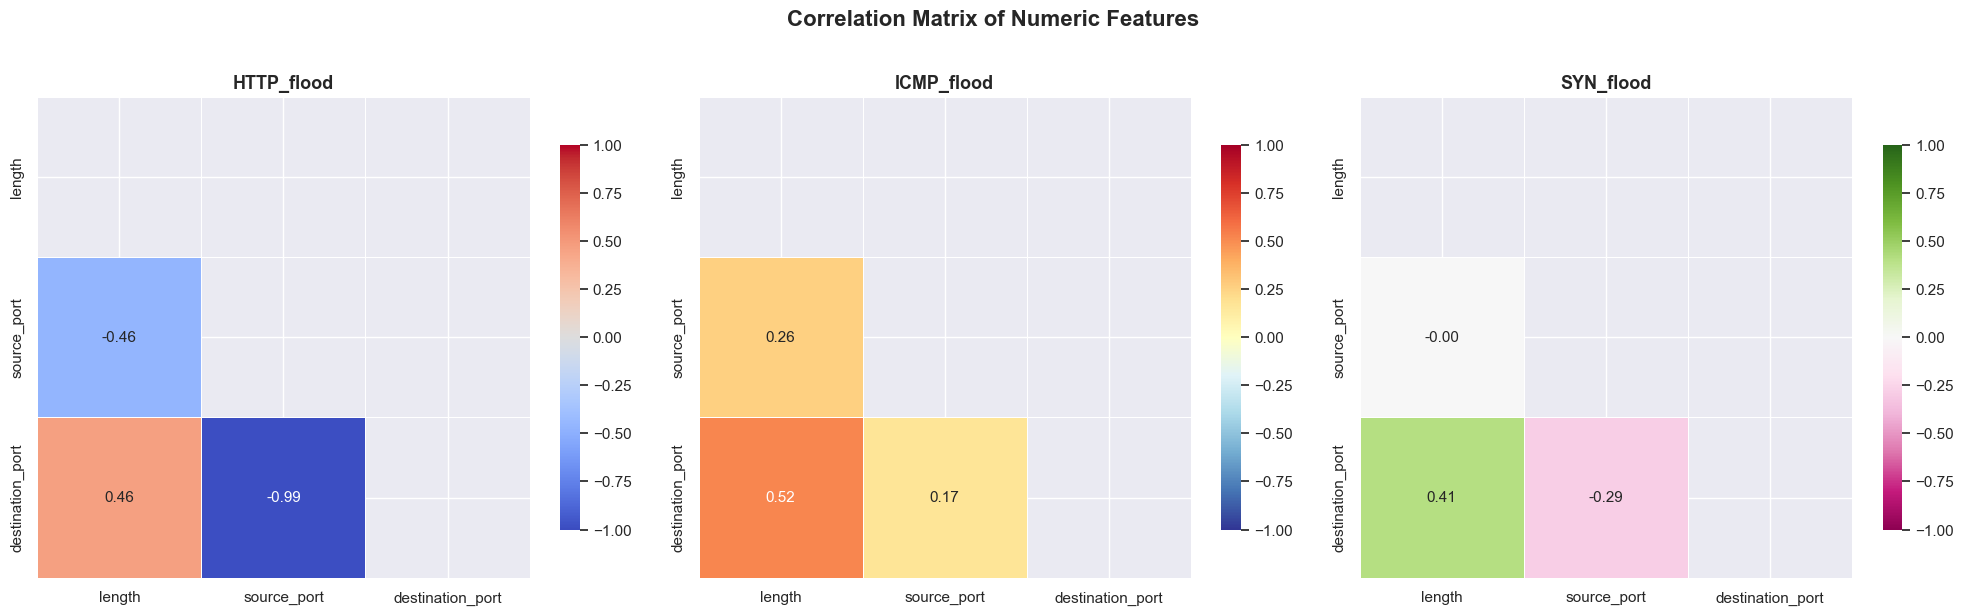

In [20]:
# Correlation heatmap of numeric columns per dataset
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold', y=1.02)

cmaps = ['coolwarm', 'RdYlBu_r', 'PiYG']
for idx, (name, df) in enumerate(dfs_cleaned.items()):
    numeric_cols = df.select_dtypes(include=['number']).columns
    corr = df[numeric_cols].corr()

    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=axes[idx], cmap=cmaps[idx],
                annot=True, fmt='.2f', linewidths=0.5,
                vmin=-1, vmax=1, center=0,
                cbar_kws={'shrink': 0.8})
    axes[idx].set_title(name, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 8.13 Source Port vs Destination Port Scatter Plot

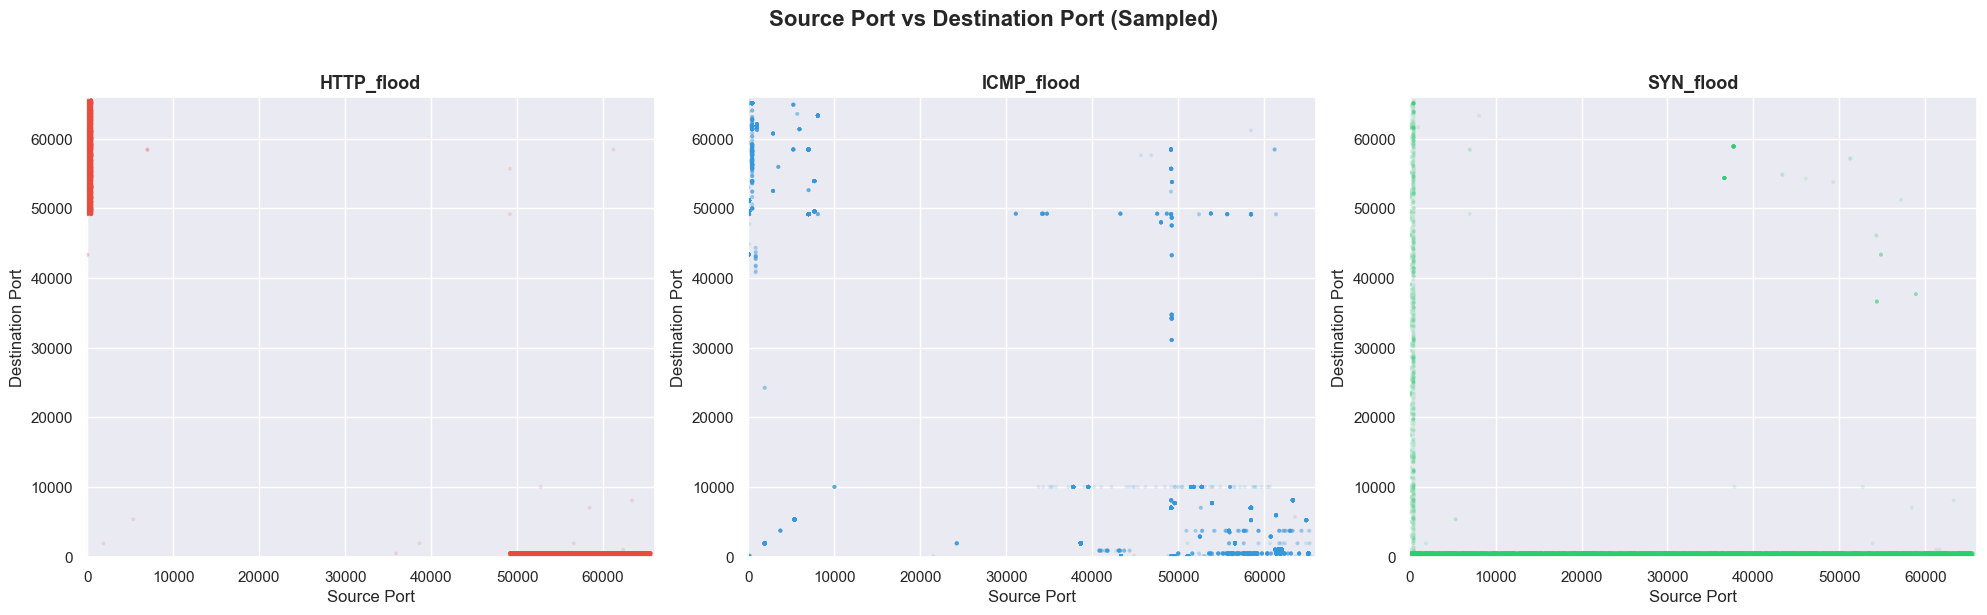

In [21]:
# Scatter plot of source port vs destination port (sampled)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Source Port vs Destination Port (Sampled)', fontsize=16, fontweight='bold', y=1.02)

colors = ['#e74c3c', '#3498db', '#2ecc71']
for idx, (name, df) in enumerate(dfs_cleaned.items()):
    df_ports = df[(df['source_port'] != -1) & (df['destination_port'] != -1)]
    if len(df_ports) == 0:
        axes[idx].text(0.5, 0.5, 'No port-based traffic', ha='center', va='center', fontsize=12)
        axes[idx].set_title(name, fontsize=13, fontweight='bold')
        continue

    sample_size = min(10000, len(df_ports))
    df_sample = df_ports.sample(n=sample_size, random_state=42)

    axes[idx].scatter(df_sample['source_port'], df_sample['destination_port'],
                      alpha=0.15, s=8, color=colors[idx], edgecolors='none')
    axes[idx].set_title(name, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Source Port')
    axes[idx].set_ylabel('Destination Port')
    axes[idx].set_xlim(-100, 66000)
    axes[idx].set_ylim(-100, 66000)

plt.tight_layout()
plt.show()

### 8.14 Cumulative Traffic Over Time

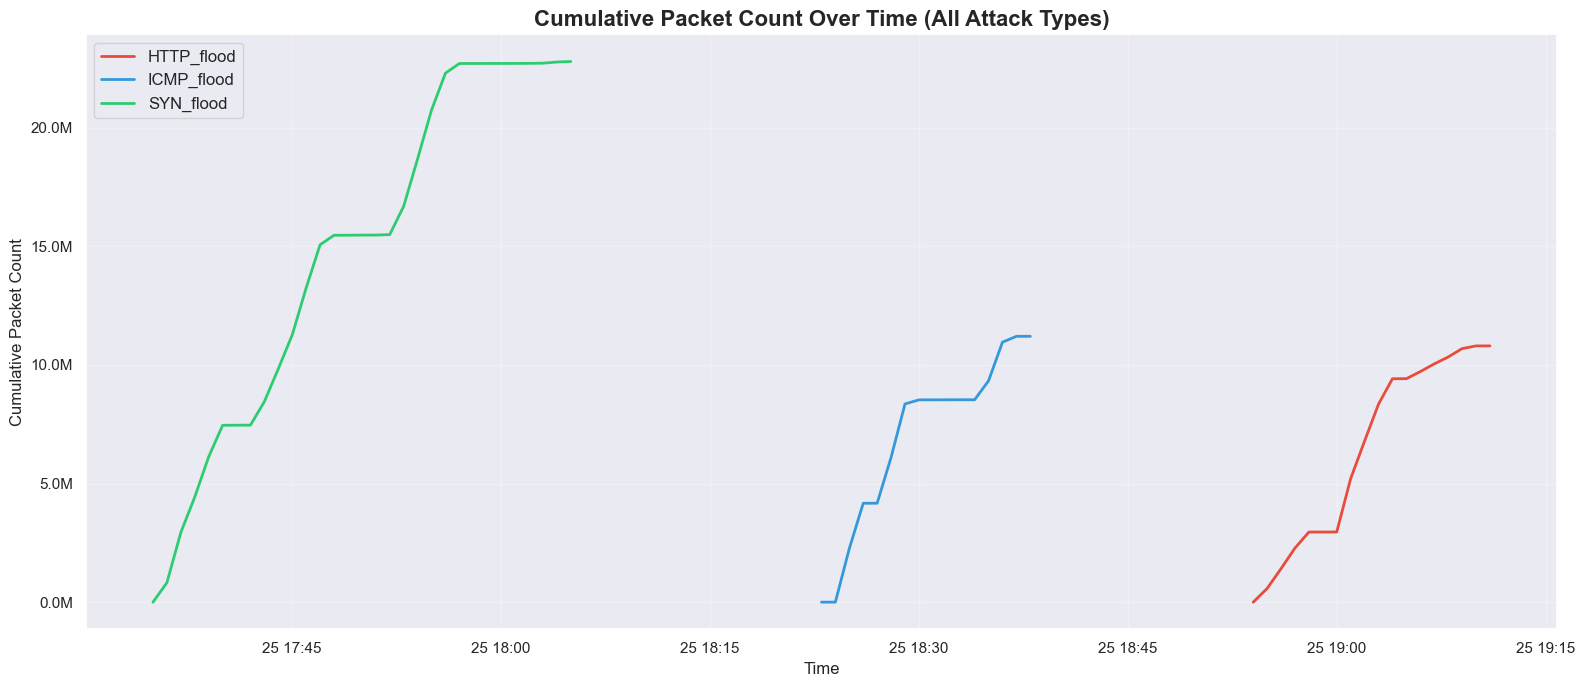

In [22]:
# Cumulative packet count over time
fig, ax = plt.subplots(figsize=(16, 7))
ax.set_title('Cumulative Packet Count Over Time (All Attack Types)', fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71']
for idx, (name, df) in enumerate(dfs_cleaned.items()):
    ts = df.set_index('time').resample('1min').size().cumsum()
    ax.plot(ts.index, ts.values, label=name, color=colors[idx], linewidth=2)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Cumulative Packet Count', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v/1e6:.1f}M'))
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.15 Packet Length Density (KDE Overlay)

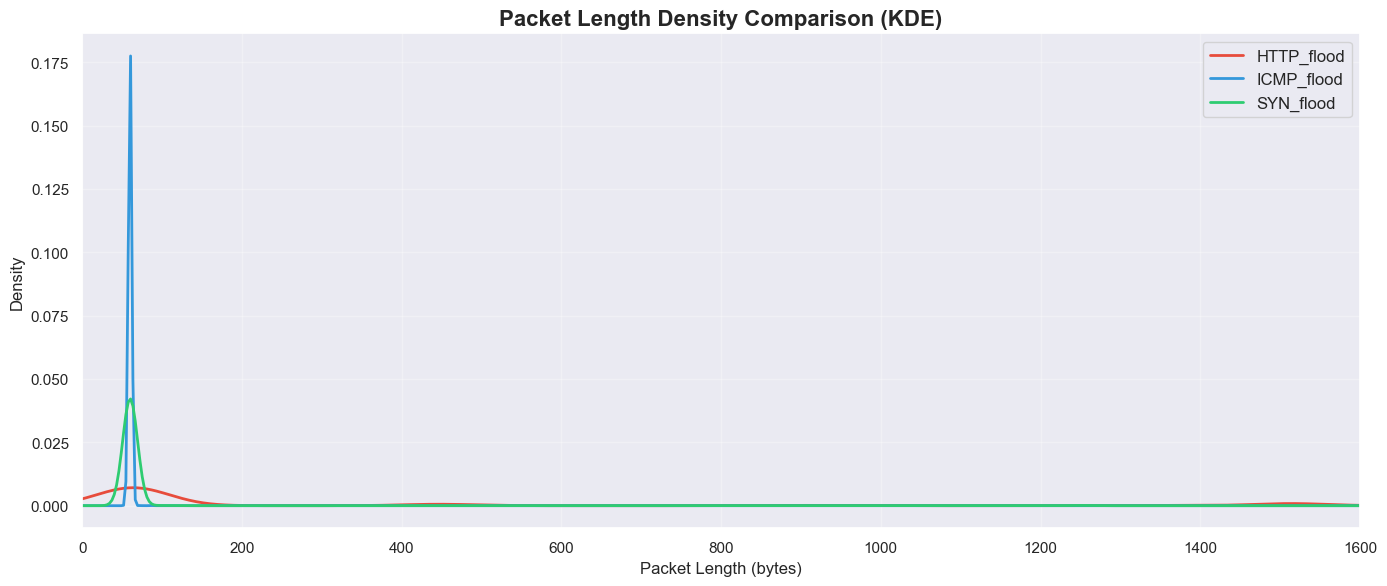

In [23]:
# KDE overlay of packet length for all three attacks
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title('Packet Length Density Comparison (KDE)', fontsize=16, fontweight='bold')

colors = ['#e74c3c', '#3498db', '#2ecc71']
for idx, (name, df) in enumerate(dfs_cleaned.items()):
    sample = df['length'].sample(n=min(100000, len(df)), random_state=42)
    sample.plot(kind='kde', ax=ax, label=name, color=colors[idx], linewidth=2)

ax.set_xlabel('Packet Length (bytes)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_xlim(0, 1600)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Export Cleaned Datasets

In [24]:
# Create output directory
OUTPUT_DIR = 'cleaned_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save individual cleaned datasets
for name, df in dfs_cleaned.items():
  output_path = os.path.join(OUTPUT_DIR, f'{name}_cleaned.csv')
  df.to_csv(output_path, index=False)
  size_mb = os.path.getsize(output_path) / (1024 * 1024)
  print(f'  Saved {output_path} ({df.shape[0]:,} rows, {size_mb:.1f} MB)')

print(f'\n[DONE] All cleaned datasets saved to "{OUTPUT_DIR}/" directory')

  Saved cleaned_data\HTTP_flood_cleaned.csv (10,799,526 rows, 795.5 MB)
  Saved cleaned_data\ICMP_flood_cleaned.csv (11,202,929 rows, 826.1 MB)
  Saved cleaned_data\SYN_flood_cleaned.csv (22,780,333 rows, 1733.4 MB)

[DONE] All cleaned datasets saved to "cleaned_data/" directory


---
## [DONE] Summary

The cleaning pipeline successfully processed all three datasets with the following operations:

| Step | Operation | Description |
|------|-----------|-------------|
| 1 | Column Name Standardization | Lowercase, underscores, no special characters |
| 2 | Drop Packet Index | Removed Wireshark `No.` column |
| 3 | Datetime Parsing | Converted `time` to `datetime64` |
| 4 | Missing Port Handling | Filled NaN -> `-1` for portless protocols (ARP, ICMP); dropped others |
| 5 | Duplicate Removal | Removed exact duplicate rows |
| 6 | Whitespace Trimming | Stripped leading/trailing whitespace from strings |
| 7 | Packet Length Validation | Removed rows with `length <= 0` |
| 8 | Port Range Validation | Ensured ports are in `0-65535` or `-1` |
| 9 | Categorical Optimization | Converted `protocol` to categorical dtype |
| 10 | Temporal Sorting | Sorted all rows by timestamp |
| 11 | Attack Labeling | Added `attack_type` column for ML readiness |

### Output Files
- `cleaned_data/HTTP_flood_cleaned.csv`
- `cleaned_data/ICMP_flood_cleaned.csv`
- `cleaned_data/SYN_flood_cleaned.csv`
- `cleaned_data/combined_all_attacks_cleaned.csv`